# 模块九：卷积神经网络（CNN）
## 9.1 卷积神经网络基本原理（第1-2课时）

---

**学习目标：**
1. 理解为什么需要卷积神经网络来处理图像数据
2. 掌握卷积操作的基本原理与数学表达
3. 理解局部感受野、权重共享、平移不变性等核心概念
4. 掌握填充（Padding）和步长（Stride）对输出的影响
5. 能够用 NumPy 从零实现 2D 卷积操作

---

## 一、从全连接到卷积：为什么需要CNN？

### 1.1 全连接层处理图像的局限性

假设我们有一张 **$28 \times 28 \times 1$** 的灰度图像（如 MNIST）：
- 展平为向量后，输入维度为 $28 \times 28 = 784$
- 如果隐藏层有 1000 个神经元，则只需 $784 \times 1000 = 784{,}000$ 个参数

但对于一张 **$224 \times 224 \times 3$** 的彩色图像（如 ImageNet）：
- 展平后输入维度为 $224 \times 224 \times 3 = 150{,}528$
- 如果第一个隐藏层有 4096 个神经元，则参数量高达 $150{,}528 \times 4096 \approx 6.2$ **亿参数！**

### 全连接层的两大问题：

| 问题 | 说明 |
|------|------|
| **参数爆炸** | 图像越大，参数量呈几何级增长，极难训练 |
| **丢失空间信息** | 将 2D 图像展平为 1D 向量，破坏了像素间的空间结构关系 |

### 1.2 对比演示：参数量计算

让我们用代码直观对比全连接网络处理不同尺寸图像时的参数量：

In [13]:
import numpy as np

print("全连接网络处理图像的参数量对比：")
print("=" * 36)

configs = [
    ("MNIST", 28, 28, 1, 1000),
    ("CIFAR-10", 32, 32, 3, 1000),
    ("ImageNet", 224, 224, 3, 4096),
]

for name, h, w, c, hidden in configs:
    input_dim = h * w * c
    params = input_dim * hidden + hidden  # 含偏置
    print(f"\n{name} ({h}×{w}×{c}) → {hidden}个神经元:")
    print(f"  输入维度: {input_dim}")
    print(f"  参数量: {params:,} (含偏置)")
    print(f"  ≈ {params/1e6:.2f}M")

print(f"\n\n而一个典型的3×3卷积层 (输入3通道, 输出64通道):")
conv_params = 3 * 3 * 3 * 64 + 64  # kernel_h * kernel_w * in_channels * out_channels + bias
print(f"  参数量: {conv_params:,} (含偏置)")
print(f"  ≈ {conv_params/1e6:.3f}M  ← 参数量极少！")

全连接网络处理图像的参数量对比：

MNIST (28×28×1) → 1000个神经元:
  输入维度: 784
  参数量: 785,000 (含偏置)
  ≈ 0.79M

CIFAR-10 (32×32×3) → 1000个神经元:
  输入维度: 3072
  参数量: 3,073,000 (含偏置)
  ≈ 3.07M

ImageNet (224×224×3) → 4096个神经元:
  输入维度: 150528
  参数量: 616,566,784 (含偏置)
  ≈ 616.57M


而一个典型的3×3卷积层 (输入3通道, 输出64通道):
  参数量: 1,792 (含偏置)
  ≈ 0.002M  ← 参数量极少！


## 二、卷积操作的基本原理

### 2.1 核心思想

卷积神经网络（Convolutional Neural Network, CNN）的设计灵感来源于**生物视觉系统**：
- 视觉皮层中的神经元只对局部区域（感受野）产生响应
- 不同神经元检测不同方向/类型的特征（边缘、纹理、形状）
- 同一类型的特征可以在图像不同位置出现（平移不变性）

### 2.2 滤波器/卷积核（Filter / Kernel）

**卷积核**是一个小尺寸的权重矩阵（如 $3 \times 3$、$5 \times 5$），它在图像上滑动，
在每个位置计算局部区域的加权和，生成**特征图（Feature Map）**。

数学表达（2D 卷积，单通道）：

$$
(I * K)(i, j) = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} I(i+m,\, j+n) \cdot K(m,\, n)
$$

其中：
- $I$：输入图像矩阵
- $K$：卷积核（大小为 $k_h \times k_w$）
- $(I * K)(i,j)$：输出特征图中位置 $(i,j)$ 的值

### 2.3 滑动窗口过程

```
输入图像 (6×6)          卷积核 (3×3)        输出特征图 (4×4)
┌─────────────┐      ┌───────────┐      ┌───────────┐
│ ■ ■ ■ ■ ■ ■ │      │ a b c     │      │ ① ② ③ ④  │
│ ■ ■ ■ ■ ■ ■ │      │ d e f     │      │ ⑤ ⑥ ⑦ ⑧  │
│ ■ ■ ■ ■ ■ ■ │      │ g h i     │      │ ⑨ ⑩ ⑪ ⑫  │
│ ■ ■ ■ ■ ■ ■ │      └───────────┘      │ ⑬ ⑭ ⑮ ⑯  │
│ ■ ■ ■ ■ ■ ■ │                         └───────────┘
│ ■ ■ ■ ■ ■ ■ │   ① = 左上3×3区域与卷积核逐元素相乘后求和
└─────────────┘   ② = 右移一格，再相乘求和...
```

### 2.4 具体数值示例

假设有一个 $5 \times 5$ 的输入图像和一个 $3 \times 3$ 的卷积核：

In [14]:
# 定义输入图像和卷积核
import numpy as np

image = np.array([
    [1, 2, 0, 1, 0],
    [0, 1, 2, 0, 1],
    [1, 0, 1, 2, 0],
    [0, 2, 0, 1, 1],
    [1, 0, 2, 1, 0],
])

kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1],
])

print("输入图像 (5×5):")
print(image)
print("\n卷积核 (3×3):")
print(kernel)
print("\n这是一个【垂直边缘检测】滤波器")

输入图像 (5×5):
[[1 2 0 1 0]
 [0 1 2 0 1]
 [1 0 1 2 0]
 [0 2 0 1 1]
 [1 0 2 1 0]]

卷积核 (3×3):
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

这是一个【垂直边缘检测】滤波器


## 三、CNN 三大核心设计原则

### 3.1 局部感受野（Local Receptive Field）

每个输出神经元只与输入的一个**小局部区域**相连，而不是与整个输入相连。

- **感受野大小** = 卷积核大小（如 $3 \times 3$）
- 随着网络加深，感受野逐渐增大：
  - 第 1 层卷积：感受野 $3 \times 3$
  - 第 2 层卷积：感受野 $5 \times 5$（在原图上）
  - 第 3 层卷积：感受野 $7 \times 7$（在原图上）

**直觉**：就像人眼看东西，先看局部细节，再组合成整体理解。

---

### 3.2 权重共享（Weight Sharing）

同一个卷积核在图像的**每个位置**使用**相同的权重参数**。

- 一个 $3 \times 3$ 卷积核只有 **9个权重参数**（加1个偏置 = 10个参数）
  - 无论图像多大，这些参数在所有位置共享使用
  - 极大减少了参数量

**类比**：就像一个"特征检测器"在整张图上滑动扫描——
同一个边缘检测器能检测图像任何位置的边缘。

---

### 3.3 平移不变性（Translation Invariance）

由于权重共享，卷积操作具有**平移不变性**（更准确地说是**平移等变性**）：

- 如果一个特征出现在图像的某个位置，
  同一个卷积核也能在其他位置检测到它
- 猫在图片左边和右边，都能被检测到

> **注意**：严格来说，卷积是**平移等变（Translation Equivariance）**的，
> 即输入平移 → 输出也平移。真正的平移不变性通常需要池化层或特殊设计来实现。

## 四、填充（Padding）与步长（Stride）

### 4.1 填充（Padding）

在输入图像周围补零，以控制输出特征图的大小。

| 类型 | 说明 | 输出大小 |
|------|------|----------|
| **Valid Padding**（无填充） | 不补零，输出变小 | $(W-K+1) \times (W-K+1)$ |
| **Same Padding**（同尺寸） | 补零使输出大小等于输入 | $W \times W$（当 $K$ 为奇数时 $P = (K-1)/2$）|

填充量计算（Same Padding，$K$ 为奇数）：
$$P = \frac{K - 1}{2}$$

### 4.2 步长（Stride）

卷积核每次滑动的步长（默认为 1）。步长越大，输出越小。

### 4.3 输出尺寸通用公式

$$O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

其中：
- $W$：输入大小
- $K$：卷积核大小
- $P$：填充量（每侧）
- $S$：步长
- $O$：输出大小
- $\lfloor \cdot \rfloor$：向下取整

In [15]:
def output_size(W, K, P, S):
    """计算卷积输出尺寸"""
    return (W - K + 2 * P) // S + 1

print("输出尺寸计算公式: O = floor((W - K + 2P) / S) + 1")
print()

test_cases = [
    (32, 3, 0, 1),
    (32, 3, 1, 1),
    (32, 3, 0, 2),
    (32, 5, 2, 1),
    (224, 7, 3, 2),
]

for W, K, P, S in test_cases:
    O = output_size(W, K, P, S)
    note = " (Same Padding)" if P == (K - 1) // 2 and S == 1 else ""
    print(f"输入: {W}×{W}, 核: {K}×{K}, Padding: {P}, Stride: {S}{note}")
    print(f"  → 输出: {O}×{O}")
    print()

输出尺寸计算公式: O = floor((W - K + 2P) / S) + 1

输入: 32×32, 核: 3×3, Padding: 0, Stride: 1
  → 输出: 30×30

输入: 32×32, 核: 3×3, Padding: 1, Stride: 1 (Same Padding)
  → 输出: 32×32

输入: 32×32, 核: 3×3, Padding: 0, Stride: 2
  → 输出: 15×15

输入: 32×32, 核: 5×5, Padding: 2, Stride: 1 (Same Padding)
  → 输出: 32×32

输入: 224×224, 核: 7×7, Padding: 3, Stride: 2
  → 输出: 112×112



## 五、特征图（Feature Map）的生成

**特征图**是卷积操作的输出，它代表了输入图像中某种特征的响应强度。

- **浅层特征图**：检测低级特征（边缘、角点、纹理）
- **深层特征图**：检测高级特征（形状、物体部位、物体）

每个卷积核生成一个特征图，多个卷积核生成多个特征图（多通道输出）。

## 六、1D、2D、3D 卷积的区别

| 类型 | 应用场景 | 输入形状 | 卷积核形状 |
|------|----------|----------|------------|
| **1D 卷积** | 时间序列、文本、信号 | $(L, C)$ | $(k, C_{in}, C_{out})$ |
| **2D 卷积** | 图像、视频帧 | $(H, W, C)$ | $(k_h, k_w, C_{in}, C_{out})$ |
| **3D 卷积** | 视频、医学影像(CT/MRI) | $(D, H, W, C)$ | $(k_d, k_h, k_w, C_{in}, C_{out})$ |

- **1D**：只在时间/序列维度上滑动
- **2D**：在高度和宽度两个维度上滑动
- **3D**：在深度、高度、宽度三个维度上滑动

## 七、Python 实战：从零实现 2D 卷积

### 7.1 手动实现 2D 卷积操作

In [16]:
import numpy as np

def conv2d_basic(image, kernel):
    """
    基础2D卷积：手动滑动窗口实现
    
    参数:
        image: 2D numpy数组, 输入图像 (H, W)
        kernel: 2D numpy数组, 卷积核 (kH, kW)
    返回:
        2D numpy数组, 输出特征图
    """
    H, W = image.shape
    kH, kW = kernel.shape
    
    # 输出尺寸（Valid Padding）
    out_H = H - kH + 1
    out_W = W - kW + 1
    
    # 初始化输出特征图
    output = np.zeros((out_H, out_W))
    
    # 滑动窗口：逐位置计算
    for i in range(out_H):
        for j in range(out_W):
            # 提取当前局部区域
            patch = image[i:i+kH, j:j+kW]
            # 逐元素相乘后求和
            output[i, j] = np.sum(patch * kernel)
    
    return output


def conv2d_padded(image, kernel, padding=0):
    """
    带填充的2D卷积
    """
    if padding > 0:
        # 在周围补零
        image = np.pad(image, padding, mode='constant', constant_values=0)
    return conv2d_basic(image, kernel)


def conv2d_stride(image, kernel, stride=1, padding=0):
    """
    带步长的2D卷积
    """
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    
    H, W = image.shape
    kH, kW = kernel.shape
    
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    
    output = np.zeros((out_H, out_W))
    
    for i in range(0, out_H * stride, stride):
        for j in range(0, out_W * stride, stride):
            patch = image[i:i+kH, j:j+kW]
            output[i // stride, j // stride] = np.sum(patch * kernel)
    
    return output

print("✅ conv2d_basic 函数定义完成")
print("✅ conv2d_padded 函数定义完成（支持 padding）")
print("✅ conv2d_stride 函数定义完成（支持 stride）")

✅ conv2d_basic 函数定义完成
✅ conv2d_padded 函数定义完成（支持 padding）
✅ conv2d_stride 函数定义完成（支持 stride）


### 7.2 手动验证卷积计算

让我们手动计算一个位置的值来验证：

In [17]:
image = np.array([
    [1, 2, 0, 1, 0],
    [0, 1, 2, 0, 1],
    [1, 0, 1, 2, 0],
    [0, 2, 0, 1, 1],
    [1, 0, 2, 1, 0],
])

kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1],
])

print("═══════ 手动验证卷积计算 ═══════")
print()

# 取左上角 3×3
patch = image[0:3, 0:3]
print("输入图像左上角3×3区域:\n", patch)
print("\n卷积核:\n", kernel)
print("\n逐元素相乘:\n", patch * kernel)
result = np.sum(patch * kernel)
print(f"\n求和: {np.sum(patch * kernel, where=(patch*kernel>0))} + {np.sum(patch * kernel, where=(patch*kernel<0))} = {result}")

# 完整卷积
output = conv2d_basic(image, kernel)
print("\n完整输出特征图:\n", output)

═══════ 手动验证卷积计算 ═══════

输入图像左上角3×3区域:
 [[1 2 0]
 [0 1 2]
 [1 0 1]]

卷积核:
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

逐元素相乘:
 [[ 1  0  0]
 [ 0  0 -2]
 [ 1  0 -1]]

求和: 2 + -3 = -1

完整输出特征图:
 [[-1.  0.  2.]
 [-2.  0.  1.]
 [-1. -2.  2.]]


### 7.3 可视化卷积过程

下面的动画展示卷积核在图像上逐步滑动的过程：

In [18]:
import numpy as np

image = np.array([
    [1, 2, 0, 1, 0],
    [0, 1, 2, 0, 1],
    [1, 0, 1, 2, 0],
    [0, 2, 0, 1, 1],
    [1, 0, 2, 1, 0],
], dtype=float)

kernel = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1],
], dtype=float)

H, W = image.shape
kH, kW = kernel.shape
out_H = H - kH + 1
out_W = W - kW + 1
output = np.zeros((out_H, out_W))

step = 0
print("\n卷积过程可视化（共{}步）：\n".format(out_H * out_W))

for i in range(out_H):
    for j in range(out_W):
        step += 1
        patch = image[i:i+kH, j:j+kW]
        val = np.sum(patch * kernel)
        output[i, j] = val
        print(f"步骤 {step}/{out_H*out_W} - 位置({i},{j}):")
        print(f"  输入区域: {patch}")
        print(f"  输出值: {val}")
        print()

print("═══ 最终输出特征图 ═══")
print(output)


卷积过程可视化（共9步）：

步骤 1/9 - 位置(0,0):
  输入区域: [[1. 2. 0.]
 [0. 1. 2.]
 [1. 0. 1.]]
  输出值: -1.0

步骤 2/9 - 位置(0,1):
  输入区域: [[2. 0. 1.]
 [1. 2. 0.]
 [0. 1. 2.]]
  输出值: 0.0

步骤 3/9 - 位置(0,2):
  输入区域: [[0. 1. 0.]
 [2. 0. 1.]
 [1. 2. 0.]]
  输出值: 2.0

步骤 4/9 - 位置(1,0):
  输入区域: [[0. 1. 2.]
 [1. 0. 1.]
 [0. 2. 0.]]
  输出值: -2.0

步骤 5/9 - 位置(1,1):
  输入区域: [[1. 2. 0.]
 [0. 1. 2.]
 [2. 0. 1.]]
  输出值: 0.0

步骤 6/9 - 位置(1,2):
  输入区域: [[2. 0. 1.]
 [1. 2. 0.]
 [0. 1. 1.]]
  输出值: 1.0

步骤 7/9 - 位置(2,0):
  输入区域: [[1. 0. 1.]
 [0. 2. 0.]
 [1. 0. 2.]]
  输出值: -1.0

步骤 8/9 - 位置(2,1):
  输入区域: [[0. 1. 2.]
 [2. 0. 1.]
 [0. 2. 1.]]
  输出值: -2.0

步骤 9/9 - 位置(2,2):
  输入区域: [[1. 2. 0.]
 [0. 1. 1.]
 [2. 1. 0.]]
  输出值: 2.0

═══ 最终输出特征图 ═══
[[-1.  0.  2.]
 [-2.  0.  1.]
 [-1. -2.  2.]]


### 7.4 用 matplotlib 可视化卷积过程与结果

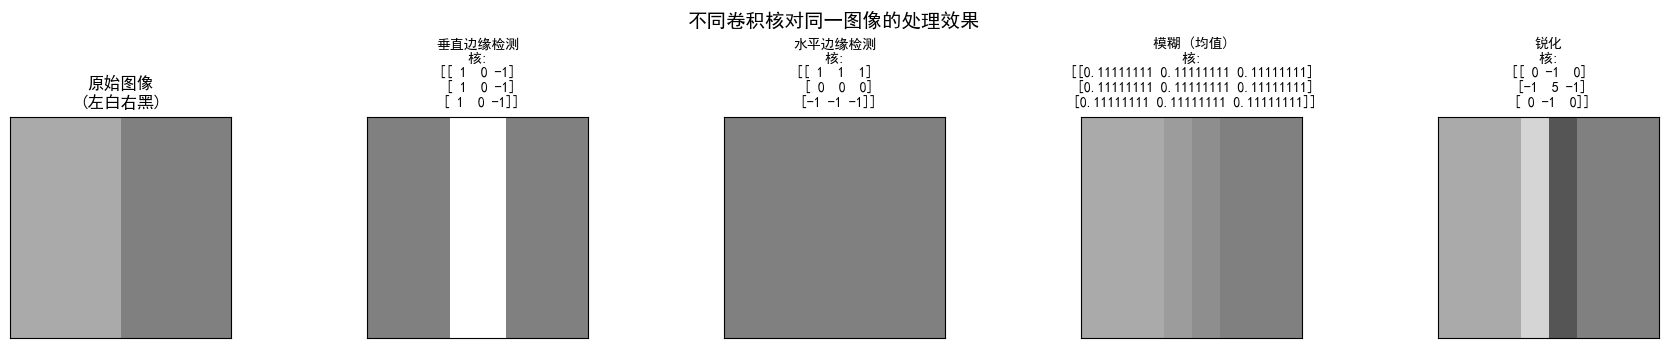

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']    # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False      # 正确显示负号

# 创建一个更大的测试图像（含明显边缘）
image = np.zeros((10, 10))
image[:, :5] = 1.0  # 左半部分亮，右半部分暗

# 定义几种经典卷积核
kernels = {
    '垂直边缘检测': np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]]),
    '水平边缘检测': np.array([[ 1,  1,  1],
                               [ 0,  0,  0],
                               [-1, -1, -1]]),
    '模糊 (均值)':   np.array([[1, 1, 1],
                               [1, 1, 1],
                               [1, 1, 1]]) / 9.0,
    '锐化':          np.array([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]]),
}

# 逐个卷积并可视化
fig, axes = plt.subplots(1, len(kernels) + 1, figsize=(18, 3.5))

# 显示原图
axes[0].imshow(image, cmap='gray', vmin=-3, vmax=3)
axes[0].set_title('原始图像\n(左白右黑)', fontsize=12, fontweight='bold')
axes[0].set_xticks([])
axes[0].set_yticks([])

for idx, (name, kernel) in enumerate(kernels.items()):
    result = conv2d_basic(image, kernel)
    axes[idx + 1].imshow(result, cmap='gray', vmin=-3, vmax=3)
    axes[idx + 1].set_title(f'{name}\n核:\n{kernel}', fontsize=10)
    axes[idx + 1].set_xticks([])
    axes[idx + 1].set_yticks([])

plt.suptitle('不同卷积核对同一图像的处理效果', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 在真实图像上展示卷积效果

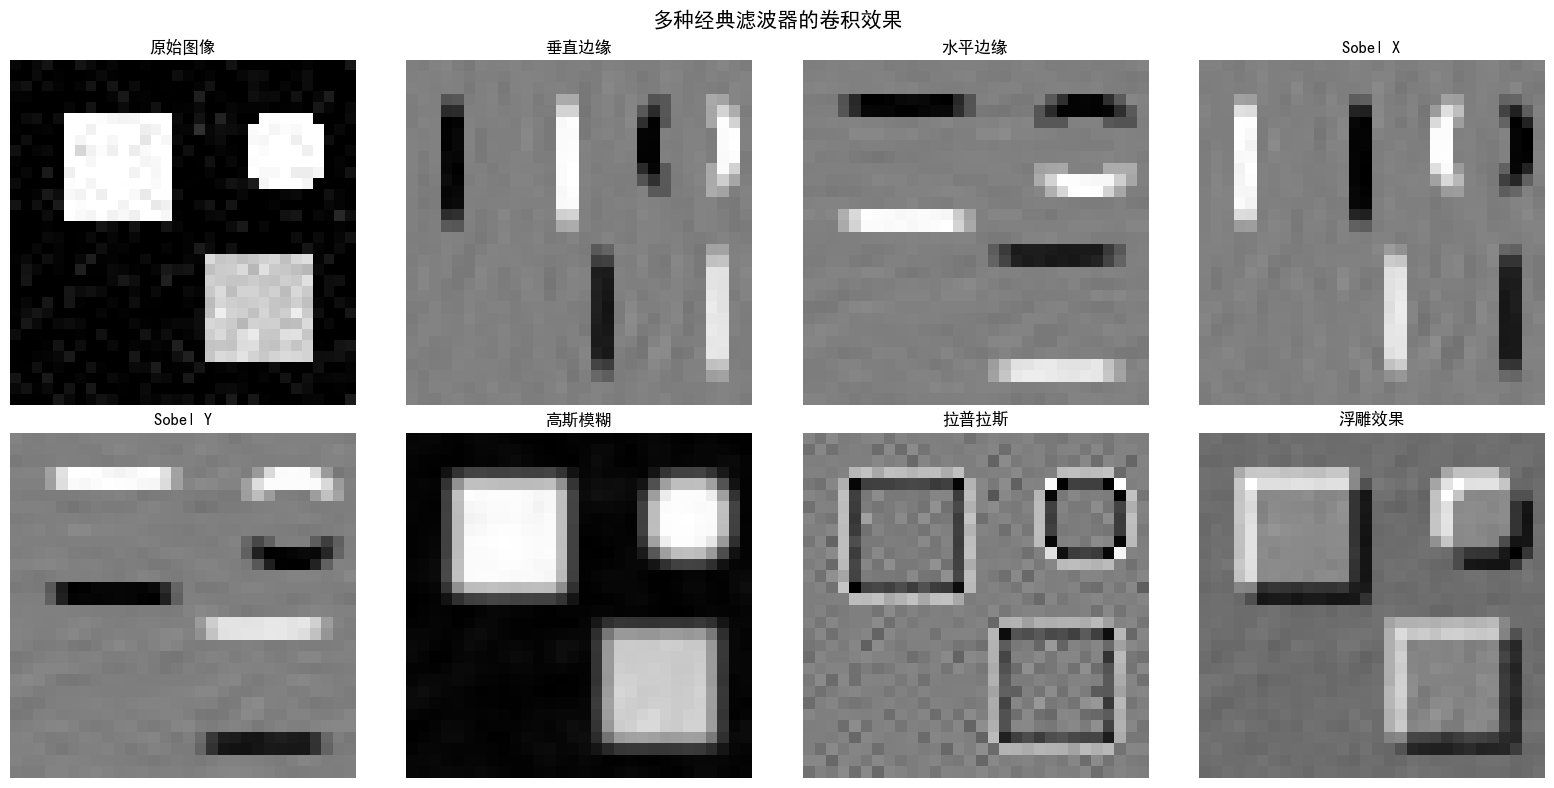

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 生成一个模拟的简单图像（带不同形状）
np.random.seed(42)
img = np.zeros((32, 32))

# 画一个白色方块
img[5:15, 5:15] = 1.0
# 画一个三角形区域
for i in range(10):
    img[18:28, 18+i:28] = 0.8
# 画一个圆形
for i in range(32):
    for j in range(32):
        if (i-8)**2 + (j-25)**2 < 16:
            img[i, j] = 1.0

# 添加少量噪声
img += np.random.normal(0, 0.05, (32, 32))
img = np.clip(img, 0, 1)

# 定义多种滤波器
filters_dict = {
    '垂直边缘': np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]),
    '水平边缘': np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]]),
    'Sobel X':  np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Sobel Y':  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    '高斯模糊': np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16.0,
    '拉普拉斯': np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    '浮雕效果': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 原图
axes[0].imshow(img, cmap='gray')
axes[0].set_title('原始图像', fontsize=12, fontweight='bold')
axes[0].axis('off')

for idx, (name, filt) in enumerate(filters_dict.items()):
    result = conv2d_basic(img, filt)
    axes[idx + 1].imshow(result, cmap='gray')
    axes[idx + 1].set_title(f'{name}', fontsize=12)
    axes[idx + 1].axis('off')

plt.suptitle('多种经典滤波器的卷积效果', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Padding 和 Stride 对输出的影响（可视化）

In [21]:
import numpy as np

# 创建测试图像
np.random.seed(0)
img = np.random.rand(8, 8)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=float)

print(f"原始图像大小: {img.shape[0]}×{img.shape[1]}")
print(f"卷积核大小: {kernel.shape[0]}×{kernel.shape[1]}")
print("=" * 45)

configs = [(0, 1), (1, 1), (2, 1), (0, 2), (1, 2)]

for P, S in configs:
    out = conv2d_stride(img, kernel, stride=S, padding=P)
    note = " (Same)" if P == 1 and S == 1 else ""
    print(f"配置{configs.index((P,S))+1}: Padding={P}, Stride={S} → 输出 {out.shape[0]}×{out.shape[1]}{note}")

print("=" * 45)
print("规律:")
print("  Padding 增大 → 输出增大")
print("  Stride 增大 → 输出减小")

原始图像大小: 8×8
卷积核大小: 3×3
配置1: Padding=0, Stride=1 → 输出 6×6
配置2: Padding=1, Stride=1 → 输出 8×8 (Same)
配置3: Padding=2, Stride=1 → 输出 10×10
配置4: Padding=0, Stride=2 → 输出 3×3
配置5: Padding=1, Stride=2 → 输出 4×4
规律:
  Padding 增大 → 输出增大
  Stride 增大 → 输出减小


### 7.7 Padding 可视化对比

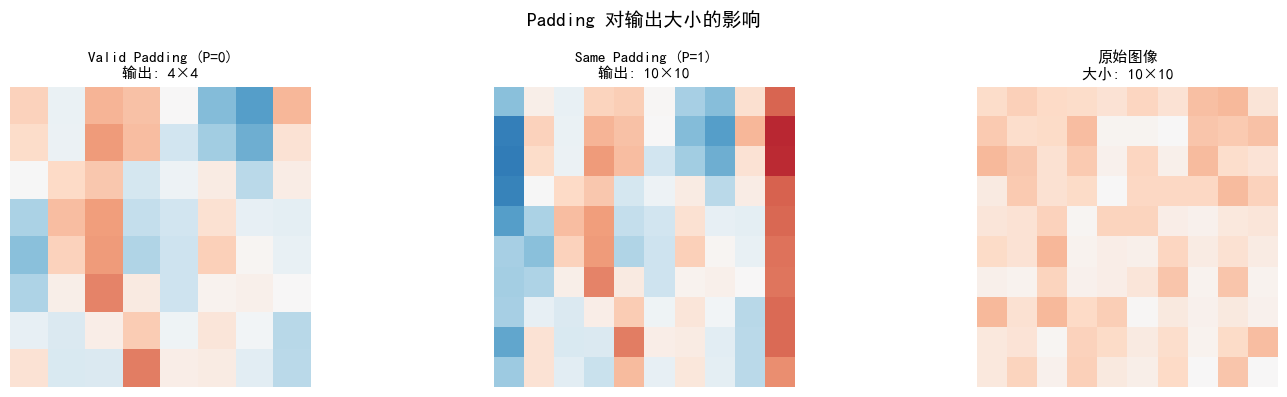

In [22]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
img = np.random.rand(10, 10)
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

out_valid = conv2d_padded(img, kernel, padding=0)
out_same  = conv2d_padded(img, kernel, padding=1)

for i, (out, title) in enumerate([
    (out_valid, f'Valid Padding (P=0)\n输出: {out.shape[0]}×{out.shape[1]}'),
    (out_same,  f'Same Padding (P=1)\n输出: {out_same.shape[0]}×{out_same.shape[1]}'),
    (img,       f'原始图像\n大小: {img.shape[0]}×{img.shape[1]}'),
]):
    axes[i].imshow(out, cmap='RdBu_r', vmin=-3, vmax=3)
    axes[i].set_title(title, fontsize=11)
    axes[i].axis('off')

plt.suptitle('Padding 对输出大小的影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 八、本节知识点总结

### 核心概念一览

| 概念 | 解释 | 优势 |
|------|------|------|
| **卷积核（Kernel）** | 小尺寸权重矩阵，滑动提取特征 | 参数少、可检测特定模式 |
| **局部感受野** | 每个神经元只看局部区域 | 保留空间结构 |
| **权重共享** | 同一核在所有位置共享参数 | 极大减少参数量 |
| **平移等变性** | 输入平移→输出平移 | 同一特征可在任意位置检测 |
| **Padding** | 输入周围补零 | 控制输出尺寸；保留边缘信息 |
| **Stride** | 卷积核滑动的步长 | 控制输出尺寸；下采样 |
| **特征图** | 卷积的输出 | 表示特征在空间上的响应强度 |

### 关键公式

- **2D 卷积**：$(I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m, n)$
- **输出尺寸**：$O = \lfloor(W - K + 2P) / S\rfloor + 1$
- **Same Padding**：$P = (K - 1) / 2$（$K$ 为奇数时）

## 九、练习题

---

### 练习 1：概念理解

**Q1.** 为什么全连接网络不适合直接处理图像数据？（列举至少 2 个原因）

**Q2.** 解释"权重共享"的含义。一个 $5 \times 5$ 卷积核处理 $100 \times 100$ 图像时，共有多少个可训练参数（含偏置）？

**Q3.** 什么是"平移等变性"？它和平移不变性有什么区别？

---

### 练习 2：计算题

**Q4.** 输入图像大小 $32 \times 32$，使用 $5 \times 5$ 卷积核，Padding=0，Stride=1，输出大小是多少？

**Q5.** 输入图像大小 $32 \times 32$，使用 $3 \times 3$ 卷积核，Padding=1，Stride=2，输出大小是多少？

**Q6.** 要让 $28 \times 28$ 的输入经过卷积后仍为 $28 \times 28$，应该使用多大的卷积核和多少 Padding？（设 Stride=1）

---

### 练习 3：编程实践

In [23]:
# 练习3：自定义卷积核

# 创建一个含十字形图案的图像
cross_image = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
], dtype=float)

# TODO: 设计一个卷积核，专门检测"水平线"
horizontal_kernel = np.array([
    # 在此填写你的 3×3 卷积核
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1],
])

print("✅ 练习3代码框架已准备好，请在下方完成代码")
print()
print("--- 答案参考 ---")
print()
print("Q4: 输出大小 = (32 - 5 + 0) / 1 + 1 = 28")
print("Q5: 输出大小 = (32 - 3 + 2) / 2 + 1 = 16")
print("Q6: K=3, P=1 (或 K=5, P=2, 等等)")
print()

# 参考答案：边缘检测核
edge_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
result = conv2d_basic(cross_image, edge_kernel)
print("自定义边缘检测核的输出:")
print(result)

✅ 练习3代码框架已准备好，请在下方完成代码

--- 答案参考 ---

Q4: 输出大小 = (32 - 5 + 0) / 1 + 1 = 28
Q5: 输出大小 = (32 - 3 + 2) / 2 + 1 = 16
Q6: K=3, P=1 (或 K=5, P=2, 等等)

自定义边缘检测核的输出:
[[-5.  4. -5.]
 [ 4.  4.  4.]
 [-5.  4. -5.]]


### 练习 4：挑战题

**Q7.** 实现一个多通道输入的卷积函数。提示：对于 RGB 图像（3通道），需要将每个通道的卷积结果相加。

In [24]:
def conv2d_multi_channel(input_img, kernel):
    """
    多通道输入的2D卷积
    
    参数:
        input_img: 3D数组 (C_in, H, W) — C_in个通道
        kernel: 3D数组 (C_in, kH, kW) — 每个输入通道一个卷积核
    返回:
        2D数组 (out_H, out_W)
    """
    C_in, H, W = input_img.shape
    _, kH, kW = kernel.shape
    
    out_H = H - kH + 1
    out_W = W - kW + 1
    output = np.zeros((out_H, out_W))
    
    # 对每个通道分别卷积，然后相加
    for c in range(C_in):
        output += conv2d_basic(input_img[c], kernel[c])
    
    return output


# 测试
rgb_input = np.zeros((3, 5, 5))
rgb_input[0, 2, 2] = 1  # R通道中心有值
rgb_input[1, 2, 2] = 1  # G通道中心有值
rgb_input[2, 2, 2] = 1  # B通道中心有值

# 全1卷积核（每个通道）
multi_kernel = np.ones((3, 3, 3)) / 9.0

result = conv2d_multi_channel(rgb_input, multi_kernel)
print(f"输入形状: {rgb_input.shape} — {rgb_input.shape[0]}通道 {rgb_input.shape[1]}×{rgb_input.shape[2]}")
print(f"卷积核形状: {multi_kernel.shape} — {multi_kernel.shape[0]}个通道的 {multi_kernel.shape[1]}×{multi_kernel.shape[2]}")
print(f"输出形状: {result.shape}")
print(f"输出:\n{result}")

输入形状: (3, 5, 5) — 3通道 5×5
卷积核形状: (3, 3, 3) — 3个通道的 3×3
输出形状: (3, 3)
输出:
[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


---

## 📚 下一节预告

在 **9.2 节** 中，我们将深入 CNN 的常用层（卷积层、池化层、全连接层），学习经典 CNN 架构，
并使用 PyTorch 搭建完整的 CNN 模型进行图像分类实战！

---

*© NOAI 竞赛课程 — 模块九：卷积神经网络*